In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 CO-LOCATED SOLAR + BESS DISPATCH & GRID CLIPPING OPTIMIZATION
PV Plant Peak:                       20.0 MWp
Substation Grid Interconnection Cap: 10.0 MW
BESS Specification:                  5.0 MW / 10.0 MWh (RTE: 90%)
---------------------------------------------------------------------------
Commercial Valuation Stack:
  • Standalone Solar Daily Revenue:  €5,874.21 / day
  • Co-located Solar + BESS Revenue: €7,333.64 / day
  • Daily Battery Value Uplift:     +€1,459.43 / day (+24.8%)
  • Curtailed Energy Recovered:      19.8 MWh / day


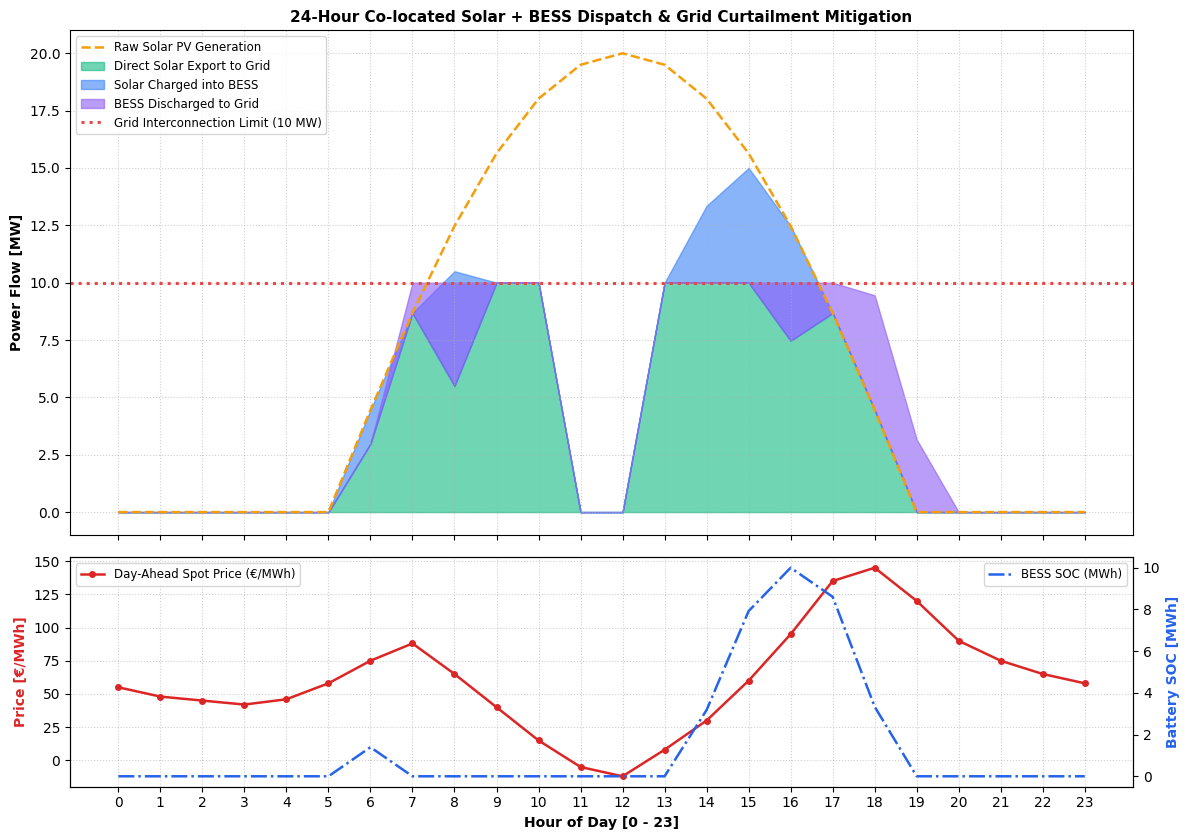

Data exported successfully.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# ==========================================================
# 1. 24-HOUR PROFILE & MULTI-CONSTRAINT DISPATCH MODELING
# ==========================================================
np.random.seed(42)
HOURS = 24
hours_arr = np.arange(HOURS)

# Technical Ratings
GRID_EXPORT_LIMIT_MW = 10.0
SOLAR_PEAK_MW = 20.0
BESS_POWER_MW = 5.0
BESS_CAPACITY_MWH = 10.0
RTE = 0.90
ETA_CH = np.sqrt(RTE)
ETA_DIS = np.sqrt(RTE)

# Synthetic Generation & Merit-Order Price Dip Profile
solar_raw = np.clip(SOLAR_PEAK_MW * np.sin(np.pi * (hours_arr - 5) / 14), 0, None)
solar_profile_mw = np.where((hours_arr >= 6) & (hours_arr <= 19), solar_raw, 0.0)

day_ahead_prices_eur_mwh = np.array([
    55.0, 48.0, 45.0, 42.0, 46.0, 58.0, 75.0, 88.0, 65.0, 40.0,
    15.0, -5.0, -12.0, 8.0, 30.0, 60.0, 95.0, 135.0, 145.0, 120.0,
    90.0, 75.0, 65.0, 58.0
])

# Linear Programming Optimization via HiGHS
T = HOURS
c = np.zeros(4 * T)
c[0:T] = -day_ahead_prices_eur_mwh        # P_solar_to_grid
c[2 * T : 3 * T] = -day_ahead_prices_eur_mwh  # P_bess_discharge

A_ub, b_ub, A_eq, b_eq = [], [], [], []

for t in range(T):
    # 1. Grid interconnection limit: P_solar_to_grid(t) + P_bess_discharge(t) <= Limit
    row_grid = np.zeros(4 * T)
    row_grid[t] = 1.0
    row_grid[2 * T + t] = 1.0
    A_ub.append(row_grid)
    b_ub.append(GRID_EXPORT_LIMIT_MW)

    # 2. Solar balance: P_solar_to_grid(t) + P_solar_to_bess(t) <= Solar(t)
    row_solar = np.zeros(4 * T)
    row_solar[t] = 1.0
    row_solar[T + t] = 1.0
    A_ub.append(row_solar)
    b_ub.append(solar_profile_mw[t])

    # 3. Dynamic SOC continuity: SOC(t) - SOC(t-1) - eta_ch*P_ch(t) + (1/eta_dis)*P_dis(t) = 0
    row_soc = np.zeros(4 * T)
    row_soc[3 * T + t] = 1.0
    if t > 0:
        row_soc[3 * T + t - 1] = -1.0
    row_soc[T + t] = -ETA_CH
    row_soc[2 * T + t] = 1.0 / ETA_DIS
    A_eq.append(row_soc)
    b_eq.append(0.0)

bounds = (
    [(0, GRID_EXPORT_LIMIT_MW) for _ in range(T)] +
    [(0, BESS_POWER_MW) for _ in range(T)] +
    [(0, BESS_POWER_MW) for _ in range(T)] +
    [(0, BESS_CAPACITY_MWH) for _ in range(T)]
)

res = linprog(
    c,
    A_ub=np.array(A_ub),
    b_ub=np.array(b_ub),
    A_eq=np.array(A_eq),
    b_eq=np.array(b_eq),
    bounds=bounds,
    method="highs"
)

if not res.success:
    raise RuntimeError(f"Optimization failed: {res.message}")

p_solar_grid = res.x[0:T]
p_solar_bess = res.x[T : 2 * T]
p_bess_dis = res.x[2 * T : 3 * T]
soc = res.x[3 * T : 4 * T]
total_export = p_solar_grid + p_bess_dis
clipped_solar = np.maximum(0.0, solar_profile_mw - (p_solar_grid + p_solar_bess))

# Baseline Standalone Solar (Unbuffered & Clipped by Grid Constraint)
standalone_export = np.minimum(solar_profile_mw, GRID_EXPORT_LIMIT_MW)
standalone_rev = np.sum(standalone_export * day_ahead_prices_eur_mwh)
optimized_rev = np.sum(total_export * day_ahead_prices_eur_mwh)
revenue_uplift = optimized_rev - standalone_rev
energy_shifted_mwh = np.sum(p_solar_bess)

# ==========================================================
# 2. COMMERCIAL VALUATION SUMMARY
# ==========================================================
print("=" * 75)
print(" CO-LOCATED SOLAR + BESS DISPATCH & GRID CLIPPING OPTIMIZATION")
print("=" * 75)
print(f"PV Plant Peak:                       {SOLAR_PEAK_MW:.1f} MWp")
print(f"Substation Grid Interconnection Cap: {GRID_EXPORT_LIMIT_MW:.1f} MW")
print(f"BESS Specification:                  {BESS_POWER_MW:.1f} MW / {BESS_CAPACITY_MWH:.1f} MWh (RTE: {RTE*100:.0f}%)")
print("-" * 75)
print("Commercial Valuation Stack:")
print(f"  • Standalone Solar Daily Revenue:  €{standalone_rev:,.2f} / day")
print(f"  • Co-located Solar + BESS Revenue: €{optimized_rev:,.2f} / day")
print(f"  • Daily Battery Value Uplift:     +€{revenue_uplift:,.2f} / day (+{(revenue_uplift/standalone_rev)*100:.1f}%)")
print(f"  • Curtailed Energy Recovered:      {energy_shifted_mwh:.1f} MWh / day")
print("=" * 75)

# ==========================================================
# 3. VISUALIZATION & ARTIFACT EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8.5), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})

# Subplot 1: Dispatch Power Stack
ax1.plot(hours_arr, solar_profile_mw, label="Raw Solar PV Generation", color="#F59E0B", linestyle="--", linewidth=1.8)
ax1.fill_between(hours_arr, 0, p_solar_grid, label="Direct Solar Export to Grid", color="#10B981", alpha=0.6)
ax1.fill_between(hours_arr, p_solar_grid, p_solar_grid + p_solar_bess, label="Solar Charged into BESS", color="#3B82F6", alpha=0.6)
ax1.fill_between(hours_arr, total_export - p_bess_dis, total_export, label="BESS Discharged to Grid", color="#8B5CF6", alpha=0.6)
ax1.axhline(GRID_EXPORT_LIMIT_MW, color="#EF4444", linestyle=":", linewidth=2.2, label=f"Grid Interconnection Limit ({GRID_EXPORT_LIMIT_MW:.0f} MW)")

ax1.set_title("24-Hour Co-located Solar + BESS Dispatch & Grid Curtailment Mitigation", fontsize=11, fontweight="bold")
ax1.set_ylabel("Power Flow [MW]", fontweight="bold")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left", frameon=True, fontsize=8.5)

# Subplot 2: Day-Ahead Spot Price & Battery State of Charge
ax2_twin = ax2.twinx()
ax2.plot(hours_arr, day_ahead_prices_eur_mwh, color="#DC2626", marker="o", markersize=4, label="Day-Ahead Spot Price (€/MWh)", linewidth=1.8)
ax2_twin.plot(hours_arr, soc, color="#2563EB", linestyle="-.", label="BESS SOC (MWh)", linewidth=1.8)

ax2.set_xlabel("Hour of Day [0 - 23]", fontweight="bold")
ax2.set_ylabel("Price [€/MWh]", color="#DC2626", fontweight="bold")
ax2_twin.set_ylabel("Battery SOC [MWh]", color="#2563EB", fontweight="bold")
ax2.set_xticks(hours_arr)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper left", frameon=True, fontsize=8.5)
ax2_twin.legend(loc="upper right", frameon=True, fontsize=8.5)

plt.tight_layout()
plt.savefig("solar_bess_co_located_dispatch_model.png", dpi=300)
plt.show()

# Export Full Schedule to CSV
df_export = pd.DataFrame({
    "hour": hours_arr,
    "day_ahead_price_eur_mwh": day_ahead_prices_eur_mwh,
    "solar_generation_mw": np.round(solar_profile_mw, 2),
    "solar_direct_export_mw": np.round(p_solar_grid, 2),
    "solar_charged_to_bess_mw": np.round(p_solar_bess, 2),
    "bess_discharge_export_mw": np.round(p_bess_dis, 2),
    "bess_soc_mwh": np.round(soc, 2),
    "total_grid_export_mw": np.round(total_export, 2),
    "grid_limit_mw": GRID_EXPORT_LIMIT_MW,
    "clipped_solar_mw": np.round(clipped_solar, 2),
    "hourly_revenue_eur": np.round(total_export * day_ahead_prices_eur_mwh, 2),
})

df_export.to_csv("solar_bess_dispatch_hourly_schedule.csv", index=False)
print("Data exported successfully.")